# The singular value decomposition

In the previous chapter on [PCA](S-PCA), we use the fact that any symmetric matrix $A$ has real eigenvalues and an associated basis of orthonormal eigenvectors. This allows us to diagonalize the matrix, i.e., write it in the form 

$$
A = PDP^{-1}
$$

where $D$ is diagonal and were $P^TP = PP^T = I$ (i.e., $P$ is an orthogonal matrix). Essentially, this shows that, when working in a basis of eigenvectors, the matrix $A$ (seen as a linear transformation) acts like a diagonal matrix. This is very important as we understand very well diagonal matrices and they are easy to work with. For example, observe that multiplying diagonal matrices (with the usual matrix product) is equivalent to multiplying the diagonal entries. In particular, if 

$$
D = \textrm{diag}(d_1,\dots,d_n) := \begin{pmatrix}
d_1 & & & \\
& d_2 & & \\
& & \ddots & \\
& & & d_n
\end{pmatrix}, 
$$

then for any integer $k \geq 1$, the matrix power $D^k$ is simply obtained by powering up each element of the diagonal, i.e., $D^k = \textrm{diag}(d_1^k, \dots, d_n^k)$. This is much easier than multiplying a general matrix $A$ by itself $k$ times. When $A$ is diagonalizable, say $A = PDP^{-1}$, observe that 

$$
A^k = \underbrace{(PDP^{-1})(PDP^{-1}) \dots (PDP^{-1})}_{\textrm{$k$ times}} = PD(P^{-1}P)D(P^{-1}P)\dots D P^{-1} = PD^kP^{-1} 
$$

since the successive terms $P^{-1}P$ cancel out. As a result, $A^k$ can be computed almost as easily as if $A$ were diagonal. If you are less familiar with these ideas, there are numerous excellent videos that explain them in greater details on the internet (see e.g. <a href="https://www.youtube.com/watch?v=EJG6gBeVdfw" target="_blank"> this one</a>).

Unfortunately, not every matrix is diagonalizable. However, as we will explain in this chapter, we can diagonalize any matrix if we are allowed to work with **two** orthonormal bases, one for the domain and one for the codomain. The resulting factorization of a matrix is called the *singular value decomposition* (SVD) and has many applications in data science. Interestingly, the factorization applies to all rectangular $m \times n$ matrices, not only square matrices. 

```{admonition} Theorem. 

Let $A \in \mathbb{R}^{m \times n}$. Then we can factor

$$
A = U \Sigma V^T, 
$$

where

1. $U \in \mathbb{R}^{m \times m}$ is an orthogonal matrix ($UU^T = U^TU = I)$. 
2. $\Sigma \in \mathbb{R}^{m \times n}$ is a rectangular diagonal matrix with non-negative diagonal. 
3. $V \in \mathbb{R}^{n \times n}$ is an orthogonal matrix ($VV^T = V^TV = I)$. 


```{figure} images/svd2.png
---
width: 400 px
---
Figure from J.M. Phillips, *Mathematical Foundations for Data Analysis*.
```

## Changing bases

Before discussing the SVD further, let us review how a linear transformation can be written with respect to different bases.

Suppose $\mathcal{B} = \{\mathbf{b}_1, \dots, \mathbf{b}_n\}$ and $\mathcal{C} = \{\mathbf{c}_1, \dots, \mathbf{c}_n\}$ are bases of $\mathbb{R}^n$. The **change of basis matrix** from $\mathcal{B}$ to $\mathcal{C}$ is denoted $P = P_{\mathcal{B} \rightarrow \mathcal{C}}$. Its columns are the vectors of $\mathcal{B}$ expressed in the basis $\mathcal{C}$:

$$
\mathbf{b}_j = p_{1j} \mathbf{c}_1 + p_{2j} \mathbf{c}_2 + \dots + p_{nj} \mathbf{c}_n.
$$

If $v \in \mathbb{R}^n$ has coordinates $(v_1, \dots, v_n)$ in basis $\mathcal{B}$, meaning

$$
v = v_1 \mathbf{b}_1 + v_2 \mathbf{b}_2 + \dots + v_n \mathbf{b}_n, 
$$

then $v$ has coordinates $Pv = (w_1, \dots, w_n)$ in basis $\mathcal{C}$, meaning 

$$
v = w_1 \mathbf{c}_1 + w_2 \mathbf{c}_2 + \dots + w_n \mathbf{c}_n.
$$

```{admonition} Remark. 
We always have $P_{\mathcal{C} \to \mathcal{B}} = P_{\mathcal{B} \to \mathcal{C}}^{-1}$ since the inverse of changing from basis $\mathcal{B}$ to basis $\mathcal{C}$ is equivalent to changing from basis $\mathcal{C}$ to basis $\mathcal{B}$.
```

```{admonition} Example.

Consider the following bases of $\mathbb{R}^2$: 

$$
\mathbf{e}_1 = \begin{pmatrix}1 \\ 0\end{pmatrix} \qquad \mathbf{e}_2 = \begin{pmatrix}0 \\ 1\end{pmatrix}
$$

and 

$$
\mathbf{f}_1 = \mathbf{e}_1 + \mathbf{e}_2 = \begin{pmatrix}1 \\ 1\end{pmatrix} \qquad \mathbf{f}_2 = \mathbf{e}_1 - \mathbf{e}_2 = \begin{pmatrix}1 \\ -1\end{pmatrix}.
$$

Let $\mathcal{B} = \{\mathbf{e}_1, \mathbf{e}_2\}$ and $\mathcal{D} = \{\mathbf{f}_1, \mathbf{f}_2\}$. To find the change of basis matrix $P_{\mathcal{B} \to \mathcal{C}}$, we need to expresse the vectors in $\mathcal{B}$ in the $\mathcal{C}$ basis. Observe that 

\begin{align*}
\mathbf{e}_1 &= \frac{1}{2}\mathbf{f}_1 + \frac{1}{2}\mathbf{f}_2 \\
\mathbf{e}_2 &= \frac{1}{2}\mathbf{f}_1 - \frac{1}{2}\mathbf{f}_2.
\end{align*}

Since the columns of $P_{\mathcal{B} \to \mathcal{C}}$ are the coordinates of the vectors in the $\mathcal{B}$ basis expressed in the $\mathcal{C}$ basis, we obtain: 

$$
P_{\mathcal{B} \to \mathcal{C}} = \begin{pmatrix}
1/2 & 1/2 \\
1/2 & -1/2
\end{pmatrix}.
$$

Observe that 

$$
P_{\mathcal{B} \to \mathcal{C}}^{-1} = P_{\mathcal{C} \to \mathcal{B}} = \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

whose columns indeed contain the coordinates of the $\mathcal{C}$ basis vectors in the $\mathcal{B}$ basis. Now, consider the vector 

$$
\mathbf{v} = 3 \mathbf{e}_1 - 2 \mathbf{e}_2. 
$$

Its coordinates are $\mathbf{v}_{\mathcal{B}} = (3,-2)^T$ in the $\mathcal{B}$ basis. To write it in the $\mathcal{C}$ basis, all we need to do is multiply it by $P_{\mathcal{B} \to \mathcal{C}}$: 

$$
\mathbf{v}_{\mathcal{C}} = P_{\mathcal{B} \to \mathcal{C}} \mathbf{v}_{\mathcal{B}} = \begin{pmatrix}
1/2 & 1/2 \\
1/2 & -1/2
\end{pmatrix} \begin{pmatrix}3 \\ -2\end{pmatrix} = \begin{pmatrix}1/2 \\ 5/2\end{pmatrix}.
$$

In other words, we have $\mathbf{v} = (1/2) \mathbf{f}_1 + (5/2) \mathbf{f}_2$, which one can readily verify. 
```

### Linear transformations 

A linear transformation between $\mathbb{R}^n$ and $\mathbb{R}^m$ is a function $f: \mathbb{R}^n \to \mathbb{R}^m$ satisfying the following two properties: 


1. $f(\mathbf{x}+\mathbf{y}) = f(\mathbf{x}) + f(\mathbf{y})$ $\forall \mathbf{x}, \mathbf{y} \in \mathbb{R}^n$.
2. $f(\lambda \mathbf{x}) = \lambda f(\mathbf{x})$ $\forall \mathbf{x} \in \mathbb{R}^n$, $\forall \lambda \in \mathbb{R}$.

If one fixes bases $\mathcal{C}$ of $\mathbb{R}^n$ and $\mathcal{D}$ of $\mathbb{R}^m$, then every matrix $A \in \mathbb{R}^{m \times n}$ defines a linear transformation via: 

$$
f(\mathbf{x}) = A \mathbf{x}. 
$$

Here, one needs to interpret the vector $\mathbf{x}$ as being written in the $\mathcal{C}$ basis, and its image $f(\mathbf{x})$ in the $\mathcal{D}$ basis. 

Conversely, given a basis $\mathcal{C} = \{\mathbf{c}_1, \dots, \mathbf{c}_n\}$ of $\mathbb{R}^n$ and $\mathcal{D}$ of $\mathbb{R}^m$, let 

$$
A = \begin{pmatrix}
\lvert & \lvert && \lvert \\
f(\mathbf{c_1}) & f(\mathbf{c_2}) &\dots& f(\mathbf{c_n})\\
\lvert & \lvert && \lvert 
\end{pmatrix}, 
$$

where the columns of $A$ are the images $f(\mathbf{c_i})$ of the basis vectors $\mathbf{c_i}$ under the map $f$, expressed in the basis $\mathcal{D}$. Then $f(\mathbf{x}) = A \mathbf{x}$. Indeed, if $\mathbf{x} = x_1 \mathbf{c}_1 + x_2 \mathbf{c}_2 + \dots + x_n \mathbf{c}_n$, then 

\begin{align*}
f(\mathbf{x}) &= f( x_1 \mathbf{c}_1 + x_2 \mathbf{c}_2 + \dots + x_n \mathbf{c}_n) \\
&= x_1 f(\mathbf{c}_1) + x_2 f(\mathbf{c}_2) + \dots + x_n f(\mathbf{c}_n) \\
&= A \mathbf{x}.
\end{align*}

There is thus a perfect correspondance between matrices and linear transformations. Thinking of matrices as linear transformations and vice-versa is a powerful way to understand these objects. For example, thinking of a matrix $A$ as a linear transformation $f$, eigenvectors become directions where $f$ "stretches" the space. 

### Performing a change of basis

Suppose $f: \mathbb{R}^n \to \mathbb{R}^m$ is a linear transformation from $V = \mathbb{R}^n$ to $W = \mathbb{R}^m$. We write it with respect to bases $\mathcal{C}$ and $\mathcal{D}$ and obtain a matrix $A$. Assume we would like to  use bases $\mathcal{B}$ and $\mathcal{E}$ instead. 

```{figure} images/change-basis.png
---
width: 400 px
---
```

In the new bases, the matrix $A$ becomes $T^{-1}AS$, where $S = P_{\mathcal{B} \to \mathcal{C}}$ and $T = P_{\mathcal{E} \to \mathcal{D}}$. Indeed, on the one hand, the matrix $A$ takes $\mathbf{x}$ (written in the $\mathcal{C}$ basis) and returns $f(\mathbf{x})$ (written in the $\mathcal{D}$ basis). On the other hand, in the computation $T^{-1}AS \mathbf{x}$: 

1. We start with the vector $\mathbf{x}$ written in the $\mathcal{B}$ basis; 
2. We apply $S$ to get the coordinates of $\mathbf{x}$ in the $\mathcal{C}$ basis. This is $S \mathbf{x}$;
3. We apply $A$ to compute $f(\mathbf{x})$, where the calculation starts in the $\mathcal{C}$ basis, and ends in the $\mathcal{D}$ basis. This is $AS\mathbf{x}$;
4. We convert the result into the $\mathcal{E}$ basis by applying $T^{-1}$. This gives $T^{-1}AS\mathbf{x}$. 

Both $A$ and $T^{-1}AS$ therefore represent the same transformation $f$. They perform the same calculation **with respect to different bases**.

In the special case where $f: \mathbb{R}^n \to \mathbb{R}^n$,  and $\mathcal{C} = \mathcal{D}$ and $\mathcal{B} = \mathcal{E}$, we obtain the following diagram:

```{figure} images/change-basis-same.png
---
width: 400 px
---
```

Given a matrix $A \in \mathbb{R}^{n \times n}$ and an invertible matrix $P \in \mathbb{R}^{n \times n}$, we can therefore think of $A$ and $P^{-1}AP$ as representing the same linear transformation with respect to two different bases. In that case, we say that the two matrices are <a href="https://en.wikipedia.org/wiki/Matrix_similarity" target="_blank">similar</a>. 

```{admonition} Example.

Consider the space $\mathbb{R}^2$ equipped with basis 

$$
\mathbf{e}_1 = \begin{pmatrix}
1 \\
0
\end{pmatrix} \qquad \mathbf{e}_2 = \begin{pmatrix}
0 \\
1
\end{pmatrix}
$$

and with basis 

\begin{align*}
\mathbf{f}_1 &= \mathbf{e}_1 + \mathbf{e}_2 \\
\mathbf{f}_2 &= \mathbf{e}_1 - \mathbf{e}_2.
\end{align*}

Let $\mathbf{x} \in \mathbb{R}^2$. Write $\mathbf{x}$ in the $\{\mathbf{e}_1, \mathbf{e}_2\}$ basis: $\mathbf{x} = x_1 \mathbf{e}_1 + x_2 \mathbf{e}_2$. Suppose, for example, that 

$$
f(\mathbf{x}) = (x_1 + 2 x_2) \mathbf{e}_1 + (3 x_1 - x_2) \mathbf{e}_2. 
$$

Then $f(\mathbf{e}_1) = \mathbf{e}_1 + 3 \mathbf{e}_2$ and $f(\mathbf{e}_2) = 2 \mathbf{e}_1-\mathbf{e}_2$. The matrix $A$ representing $f$ with respect to bases $\mathcal{C} = \mathcal{D} = \{\mathbf{e}_1, \mathbf{e}_2\}$ is therefore 

$$
A = \begin{pmatrix}
1 & 2 \\
3 & -1
\end{pmatrix}.
$$

Now, we already have the coordinates of the $\{\mathbf{f}_1, \mathbf{f}_2\}$ basis in the $\{\mathbf{e}_1, \mathbf{e}_2\}$ basis. This gives us the $P_{\mathcal{B} \to \mathcal{C}}$ matrix: 

$$
S = P_{\mathcal{B} \to \mathcal{C}} = \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}.
$$

We also have $T = P_{\mathcal{E} \to \mathcal{D}} = P_{\mathcal{B} \to \mathcal{C}} = S$. Therefore, the matrix 

$$
T^{-1} A S = S^{-1} A S = \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}^{-1} A \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix} = \begin{pmatrix}
5/2 & 3/2 \\
1/2 & -5/2
\end{pmatrix}
$$

represents the linear transformation $f$ in the $\{\mathbf{f}_1, \mathbf{f}_2\}$ basis. Let us verify if that works. Consider, for example, the vector $\mathbf{x} = 0 \mathbf{e}_1 + 2 \mathbf{e}_2$. Then 

$$
f(\mathbf{x}) = \begin{pmatrix}
1 & 2 \\
3 & -1
\end{pmatrix} \begin{pmatrix}
0 \\
2
\end{pmatrix} = \begin{pmatrix}4 \\ -2 
\end{pmatrix} = 4 \mathbf{e}_1 -2 \mathbf{e}_2. 
$$

Let us now do the same calculation using the $\mathcal{B} = \mathcal{E} = \{\mathbf{f}_1, \mathbf{f}_2\}$ basis. Observe that $\mathbf{x} = \mathbf{f}_1 - \mathbf{f}_2$. Thus, the coordinates of $\mathbf{x}$ in the $\{\mathbf{f}_1, \mathbf{f}_2\}$ basis are $(1,-1)^T$. Hence, the coordinates of $f(\mathbf{x})$ in the $\{\mathbf{f}_1, \mathbf{f}_2\}$ basis are 

$$
\begin{pmatrix}
5/2 & 3/2 \\
1/2 & -5/2
\end{pmatrix}\begin{pmatrix}
1 \\ 
-1
\end{pmatrix} = \begin{pmatrix}
1 \\ 3
\end{pmatrix} = \mathbf{f}_1 + 3\mathbf{f}_2. 
$$

Observe that we indeed have $\mathbf{f}_1 + 3\mathbf{f}_2 = 4 \mathbf{e}_1 -2 \mathbf{e}_2$. We therefore obtain the same value of $f(\mathbf{x})$, computed with respect to the two different bases.
```

```{admonition} Definition. 

A matrix $A \in \mathbb{R}^{n \times n}$ is said to be *diagonalizable* if there exists an invertible matrix $P \in \mathbb{R}^{n \times n}$ and a diagonal matrix $D$ such that $P^{-1} A P = D$. 
```

In other words, a matrix $A$ is diagonalizable if it is diagonal with respect to some basis. One can show that a matrix is diagonalizable if and only if its eigenvectors form a basis of $\mathbb{R}^n$.

```{admonition} Theorem.

A matrix $A \in \mathbb{R}^{n \times n}$ is diagonalizable if and only if $\mathbb{R}^n$ has a basis consisting of eigenvectors of $A$.
```

```{admonition} Example.

Consider the following two matrices:

$$
A =
\begin{pmatrix}
1 & 1 \\
1 & 1
\end{pmatrix},
\qquad
B = 
\begin{pmatrix}
0 & 1 \\
0 & 0
\end{pmatrix}.
$$

One can verify that the eigenvalues of $A$ are

$$
\lambda_1 = 2,\qquad \lambda_2 = 0,
$$

with corresponding eigenvectors

$$
v_1 = \begin{pmatrix}1\\1\end{pmatrix},
\qquad
v_2 = \begin{pmatrix}1\\-1\end{pmatrix}.
$$

Since $A$ has two linearly independent eigenvectors, $A$ is diagonalizable. Writing these eigenvectors as the columns of $P$ and the eigenvalues in $D$,

$$
P = \begin{pmatrix}1 & 1 \\[4pt] 1 & -1\end{pmatrix}, \qquad
D = \begin{pmatrix}2 & 0 \\[4pt] 0 & 0\end{pmatrix},
$$

we have

$$
A = P D P^{-1}.
$$

On the other hand, the eigenvalues of $B$ are

$$
\lambda_1 = \lambda_2 = 0.
$$

To find the eigenvectors, note that

$$
(B - 0I) x = 
\begin{pmatrix}
0 & 1 \\
0 & 0
\end{pmatrix}\begin{pmatrix}
x_1 \\
x_2\end{pmatrix} = \begin{pmatrix}x_2 \\ 0\end{pmatrix} = \begin{pmatrix}0 \\ 0\end{pmatrix}. 
$$

Thus $x_2 = 0$ and every eigenvector is of the form

$$ 
x = 
\begin{pmatrix}
x_1 \\ 0
\end{pmatrix}
$$

for some $x_1 \ne 0$. The eigenspace of $B$ associated to $\lambda_1 = \lambda_2 = 0$ is therefore one-dimensional, spanned by

$$
v = 
\begin{pmatrix}
1 \\ 0
\end{pmatrix}.
$$

Because $B$ has only one linearly independent eigenvector, it is **not** diagonalizable.
```

## Back to the SVD

Now, let $A \in \mathbb{R}^{m \times n}$. The SVD diagonalizes $A$ with respect to **two different** orthonormal bases of $\mathbb{R}^n$ and $\mathbb{R}^m$. Assuming $A$ represents a linear transformation with respect to bases $\mathcal{C}$ and $\mathcal{D}$ of $\mathbb{R}^n$ and $\mathbb{R}^m$ respectively, we can construct new orthonormal bases $\mathcal{B}$ and $\mathcal{E}$ of $\mathbb{R}^n$ and $\mathbb{R}^m$ such that the matrix $A$ becomes (rectangular) diagonal after the change of basis:

```{figure} images/change-basis-svd.png
---
width: 400 px
---
```

We therefore obtain $A = U\Sigma V^T$ where:  

1. $U \in \mathbb{R}^{m \times m}$ is an orthogonal matrix ($UU^T = U^TU = I)$. 
2. $\Sigma \in \mathbb{R}^{m \times n}$ is a rectangular diagonal matrix with non-negative diagonal. 
3. $V \in \mathbb{R}^{n \times n}$ is an orthogonal matrix ($VV^T = V^TV = I)$. 

The columns of $U$ are called the *left singular vectors* of $A$, the columns of $V$ the *right singular vectors* of $A$, and the diagonal elements of $\Sigma$ the *singular values* of $A$.

The function *numpy.linalg.svd* computes the SVD of a matrix. For example: 

In [90]:
import numpy as np

A = np.array([[1,2],[3,1],[0,4]])
U, S, Vt = np.linalg.svd(A)

# Note: S is a vector containing the singular values of A. 
Sigma = np.zeros((3,2))
Sigma[0:2,0:2] = np.diag(S)

We can now verify that $A = U\Sigma V^T$: 

In [91]:
A-U.dot(Sigma).dot(Vt)

array([[-2.22044605e-16,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [-6.53512448e-17,  0.00000000e+00]])

## Applications of the SVD

The SVD has many interesting applications in data science. We will briefly survey 2 of them.

### Best rank $k$ approximation

```{admonition} The rank of a matrix

Recall that the <a href="https://en.wikipedia.org/wiki/Rank_(linear_algebra)" target="_blank">rank</a> of a matrix $A \in \mathbb{R}^{m \times n}$ is the dimension of the space spanned by its columns (or, equivalently, by its rows). In particular, the rank of a $m \times n$ matrix is at most $\min(m,n)$. 
```

Let $X \in \mathbb{R}^{n \times p}$ be a usual "data matrix". Let $X = U \Sigma V^T = \sum_{i=1}^{\min(n,p)} \sigma_i u_i v_i^T$ be the SVD of $X$, where $\sigma_1 \geq \sigma_2 \geq \dots \geq \sigma_{\min(n,p)} \geq 0$ are the singular values of $X$. For $1 \leq k \leq \min(n,p)$, define the **$k$-th truncated SVD** of $X$ by:

$$
X_k  = \sum_{i=1}^k \sigma_i u_i v_i^T.
$$

Then the matrix $X_k$ is the "best" approximation of $X$ by a matrix of rank at most $k$. To make the result precise, we measure the distance between matrices using two norms: the Frobenius norm $\|\cdot\|_F$ and the spectral norm $\|\cdot\|_2$:  

\begin{align*}
\|X\|_F &= \left(\sum_{i=1}^n \sum_{j=1}^p |X_{ij}|^2\right)^{1/2} \\
\|X\|_2 &= \sigma_\textrm{max}(A) = \lambda_\textrm{max}(A^TA)^{1/2}, 
\end{align*}

where $\sigma_\textrm{max}(A)$ denotes the largest singular value of $A$, i.e., the square root of the largest eigenvalue $\lambda_\textrm{max}(A^TA)$ of $A^TA$. Both norms are commonly used to measure the magnitude of a matrix. 

```{admonition} Theorem. 

Let $X \in \mathbb{R}^{n \times p}$ and let $X_k$ be its $k$-th truncated SVD. Then

\begin{align*}
&\min_{\substack{B \in \mathbb{R}^{n \times p} \\ \textrm{rank}(B) \leq k}} \|X - B\|_F^2 = \|X-X_k\|_F^2 = \sum_{j=k+1}^p \sigma_j^2 \\
&\min_{\substack{B \in \mathbb{R}^{n \times p} \\ \textrm{rank}(B) \leq k}} \|X - B\|_2 = \|X-X_k\|_2 = \sigma_{k+1}.
\end{align*}
```

In other words, the truncated SVD provides the *best rank $k$ approximation* to $X$. This result has many important applications in data compression, data recovery, etc..

To illustrate the above, consider the following image

```{figure} images/landscape.jpg
---
width: 600 px
---
```

Let us load this image into Python, convert it to a matrix, and compute its SVD.

In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import PIL

im = Image.open("landscape.jpg").convert('L')

img = np.asarray(im)

# Compute the SVD
u, s, vt = np.linalg.svd(img)

Next, let us use the singular values to compute the Frobenius error made by a rank $k$ approximation: 

Text(0, 0.5, 'Fraction of error (Frobenius norm)')

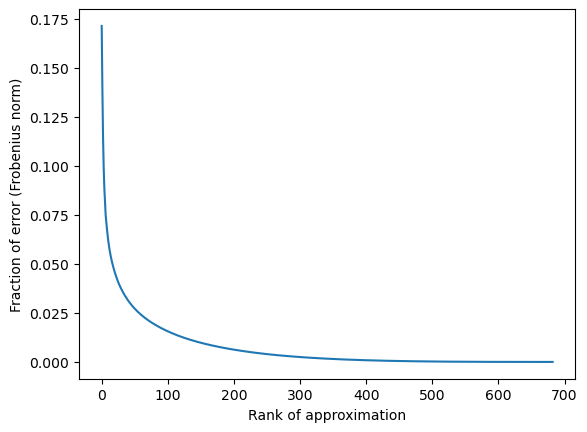

In [8]:
frob_error = 1-np.cumsum(s**2)/sum(s**2)
plt.figure()
plt.plot(frob_error)
plt.xlabel("Rank of approximation")
plt.ylabel("Fraction of error (Frobenius norm)")

Observe how the error decreases rapidely as the rank increases. This shows that the image has a "hidden" low rank structure and can be approximated well using lower rank images. This is a very common phenomenon. Let us diplay some of these approximations.

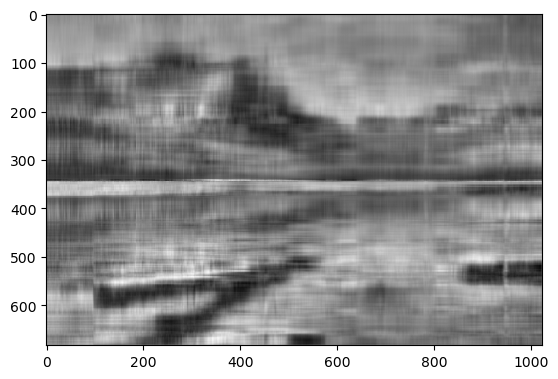

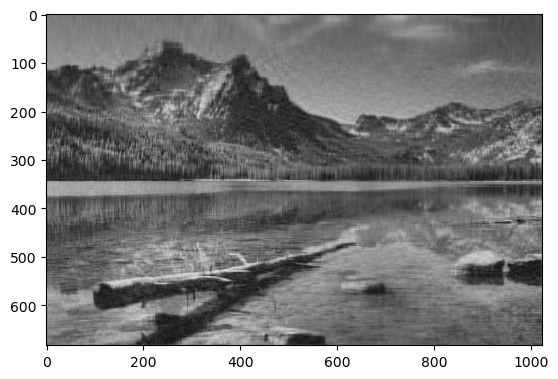

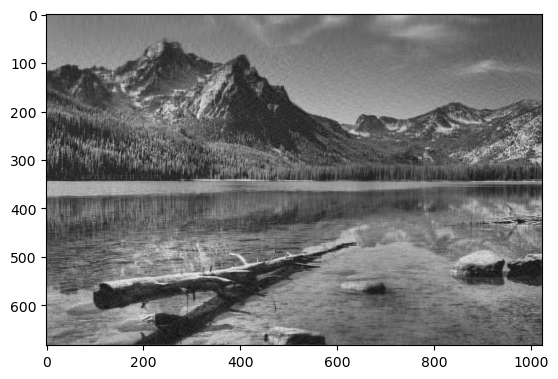

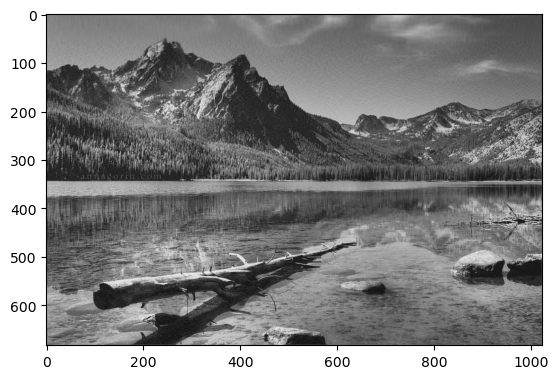

In [11]:
# Truncates a SVD to k singular values from its factors u, s, vt
def tsvd(u, s, vt, k):
	n = u.shape[0]
	p = vt.shape[0]
	sdiag = np.zeros((n,p))
	for i in range(k):
		sdiag[i,i] = s[i]
	
	return(u.dot(sdiag).dot(vt))

img_10 = tsvd(u,s,vt, 10)
img_50 = tsvd(u,s,vt, 50)
img_100 = tsvd(u,s,vt, 100)
img_200 = tsvd(u,s,vt, 200)
img_300 = tsvd(u,s,vt, 300)
img_400 = tsvd(u,s,vt, 400)
img_500 = tsvd(u,s,vt, 500)
img_600 = tsvd(u,s,vt, 600)
img_683 = tsvd(u,s,vt, 683)

# Rank 10 approximation
plt.figure()
plt.imshow(img_10, cmap='gray')

# Rank 50 approximation
plt.figure()
plt.imshow(img_50, cmap='gray')

# Rank 100 approximation
plt.figure()
plt.imshow(img_100, cmap='gray')

# Rank 200 approximation
plt.figure()
plt.imshow(img_200, cmap='gray')

Even though the lower rank approximations lose some of the details of the image, for machine learning purposes (say, detecting objects), the rank 50 approximation already provides an excellent approximation!

### Recommendation systems

The SVD and variants can be used to construct various recommender systems. For example, consider the problem of recommending movies to watch based on a person's previous rankings. Let $X_{ij}$ be the ranking of person $i$ for movie $j$:  

```{figure} images/movie-matrix.png
---
width: 500 px
---
```

This matrix has a lot of missing entries as each person has probably only seen only a small subset of the considered movies. The goal of a recommender system is to predict the missing rankings to recommend new movies to watch to each user. This problem became very popular in the early days of the company Netflix when they offered a 1 million dollar prize to anybody who could improve their own algorithm by at least 10% (see the <a href="https://en.wikipedia.org/wiki/Netflix_Prize" target="_blank">Netflix prize</a>).

One can think of the SVD as explaining the data as follows: 

1. Each movie is a combination of some unknown independent ``basic features''  (e.g. action, explosions, nature, romance, etc.)
2. Each features has a degree of importance (weights).
3. Each person likes a given combination of the basic features. 

Letting $X_{n \times p} = U_{n \times n} \Sigma_{n \times p} V_{p \times p}^T$ be the SVD of the ranking matrix $X$, we have: 

```{figure} images/svd-movie.png
---
width: 300 px
---
```

In a practical application where the matrix $X$ is only partially observed, one can optimize over the different factors $U, \Sigma, V^T$ so that the matrix $U\Sigma V^T$ approximates the observed entries of $X$ as accurately as possible. This provides a estimation of the missing entries that can then be used to make recommendations.

Once a factorization of $X$ has been obtained, observe that the matrix $V$ contains the "amount" of each features that are contained in each movie. Using knowledge of the movies, one can try to label these features. For example, if a lot of the movies with a lot of "feature 1" are westerns with a love story, one could label feature 1 as something like "critically acclaimed western with a romantic component". You may have seen such "non-traditional" labels on streaming platforms. 

